In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
df = pd.read_csv('/content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/metadata.csv')
df.head()

,image_path,group_id,transform,is_original,blurred,brightened,contrasted,cropped,original
0,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,original,1,0,0,0,0,1
1,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,blurred,0,1,0,0,0,0
2,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,brightened,0,0,1,0,0,0
3,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,contrasted,0,0,0,1,0,0
4,/content/drive/MyDrive/copydays-ndid/NDID_6000...,IMAGE_00000,cropped,0,0,0,0,1,0


In [6]:
image_paths = df['image_path'].values

In [7]:
import numpy as np
np.random.shuffle(image_paths)

In [8]:
class UnlabeledImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform or preprocess

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, str(path)

In [9]:
dataset = UnlabeledImageDataset(image_paths)
loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

batch = next(iter(loader))
imgs, paths = batch

print("Batch tensor shape:", imgs.shape)
print("Sample path:", paths[0])

Batch tensor shape: torch.Size([32, 3, 224, 224])
Sample path: /content/drive/MyDrive/copydays-ndid/NDID_6000_image_data_set/augmented/IMAGE_00003/blurred.jpg


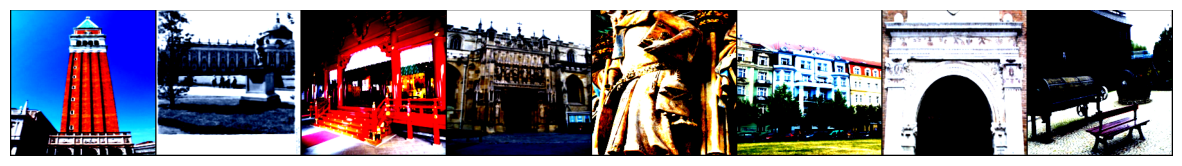

In [10]:
import torchvision

def show_batch(images, n=8):
    grid = torchvision.utils.make_grid(images[:n], nrow=n)
    plt.figure(figsize=(15, 3))
    plt.imshow(grid.permute(1,2,0))
    plt.axis('off')
    plt.show()

show_batch(imgs)